# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_4_WVI Perception Inference Analytics

This notebook benchmarks multiple regression models for predicting WVI perception scores from geospatial and visual features, and evaluates their performance using R² and RMSE.

Data source used in this notebook:
- `data/data_final_rescaled.csv` (rescaled perception and geospatial data for each WVI)

## 0. Plotting Configuration

Run plotting configuration first - Set up the overall style of figures.

In [1]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
sns.set_palette(OKABE_ITO)

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4

from pathlib import Path

def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

## 1. Inference Modelling
#### Load data

In [28]:
import pandas as pd

df = pd.read_csv('data/data_final.csv')

perception_cols = ['Prefer', 'Monotonous', 'Quiet', 'Extensive', 'Vivid', 'Oppressive']
feature_cols = [
    'WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground',
    'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior',
    'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland',
    'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI'
]

Y = df[perception_cols]
X = df[feature_cols]

print(f"Dataset: {len(df)} samples, {len(feature_cols)} features, {len(perception_cols)} targets")
print(f"Features: {feature_cols}")
print(f"\nY descriptive statistics:")
print(Y.describe().T.to_string())

Dataset: 12334 samples, 23 features, 6 targets
Features: ['WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground', 'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior', 'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland', 'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI']

Y descriptive statistics:
              count      mean       std       min       25%       50%       75%        max
Prefer      12334.0  4.520228  1.608141  1.583325  3.194445  4.306091  5.686498   9.728552
Monotonous  12334.0  4.976050  1.315977  2.053955  3.928379  4.746871  5.851425   9.835099
Quiet       12334.0  4.324172  1.301996  2.069345  3.355732  3.932705  5.002731  10.288339
Extensive   12334.0  4.935909  2.028063  0.856272  3.154460  4.677665  6.654583  10.132759
Vivid       12334.0  5.079991  1.648189  1.904558  3.685046  4.938328  6.329878  10.718850
Oppressive  12334.0  4.896949  1.988105  1.387189  3.014756  4.958

#### Model Regression Benchmark

We train and evaluate seven regression models: Ridge, Lasso, ElasticNet, PLS, Random Forest, SVR, and XGBoost.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 8633 samples | Test: 3701 samples


In [23]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tqdm import tqdm

steps = [
    ('Ridge',        lambda: Ridge(alpha=1.0)),
    ('Lasso',        lambda: Lasso(alpha=0.1)),
    ('ElasticNet',   lambda: ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('PLS',          lambda: PLSRegression(n_components=min(10, X_train.shape[1]))),
    ('RandomForest', lambda: RandomForestRegressor(n_estimators=100, random_state=42)),
]

preds = {}
with tqdm(steps, desc='Training linear/ensemble models') as pbar:
    for name, model_fn in pbar:
        pbar.set_postfix(model=name)
        m = model_fn()
        m.fit(X_train, Y_train)
        preds[name] = m.predict(X_test)

Y_pred_ridge       = preds['Ridge']
Y_pred_lasso       = preds['Lasso']
Y_pred_elastic_net = preds['ElasticNet']
Y_pred_pls         = preds['PLS']
Y_pred_rf          = preds['RandomForest']

Y_pred_svr, Y_pred_xgb = [], []
targets = list(range(Y_train.shape[1]))
for i in tqdm(targets, desc='Training SVR & XGBoost per target'):
    svr = SVR(kernel='rbf')
    svr.fit(X_train, Y_train.iloc[:, i])
    Y_pred_svr.append(svr.predict(X_test))

    xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb_reg.fit(X_train, Y_train.iloc[:, i])
    Y_pred_xgb.append(xgb_reg.predict(X_test))

Y_pred_svr = np.column_stack(Y_pred_svr)
Y_pred_xgb = np.column_stack(Y_pred_xgb)

print('All models trained.')

Training SVR & XGBoost per target: 100%|██████████| 6/6 [00:22<00:00,  3.67s/it]

All models trained.


#### Model Evaluation — R² and RMSE

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    'Ridge': Y_pred_ridge,
    'Lasso': Y_pred_lasso,
    'ElasticNet': Y_pred_elastic_net,
    'PLS': Y_pred_pls,
    'RandomForest': Y_pred_rf,
    'SVR': Y_pred_svr,
    'XGBoost': Y_pred_xgb,
}

r2_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)
rmse_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)

for model_name, Y_pred in models.items():
    for i, col in enumerate(perception_cols):
        y_true = Y_test[col]
        y_pred = Y_pred[:, i] if Y_pred.ndim == 2 else Y_pred
        r2_scores.loc[model_name, col] = r2_score(y_true, y_pred)
        rmse_scores.loc[model_name, col] = np.sqrt(mean_squared_error(y_true, y_pred))

print("R² Scores:")
print(r2_scores.astype(float).round(4).to_string())
print("\nRMSE Scores:")
print(rmse_scores.astype(float).round(4).to_string())

R² Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         0.5406      0.1752  0.4889     0.6767  0.4099      0.6099
Lasso         0.5221      0.1588  0.4582     0.6617  0.3953      0.5970
ElasticNet    0.5323      0.1701  0.4779     0.6706  0.4065      0.6030
PLS           0.5399      0.1749  0.4883     0.6766  0.4078      0.6087
RandomForest  0.6098      0.2645  0.5319     0.7155  0.4940      0.6664
SVR           0.6005      0.2546  0.5145     0.7108  0.4938      0.6602
XGBoost       0.6306      0.2950  0.5464     0.7270  0.5272      0.6836

RMSE Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         1.0827      1.1789  0.9204     1.1394  1.2637      1.2317
Lasso         1.1043      1.1906  0.9476     1.1655  1.2792      1.2518
ElasticNet    1.0924      1.1826  0.9302     1.1500  1.2673      1.2425
PLS           1.0835      1.1792  0.9209     1.1396  1.2659      1.2334
RandomForest  0.9978      1.1133  0.880

#### Model Visualisation — R² Heatmap

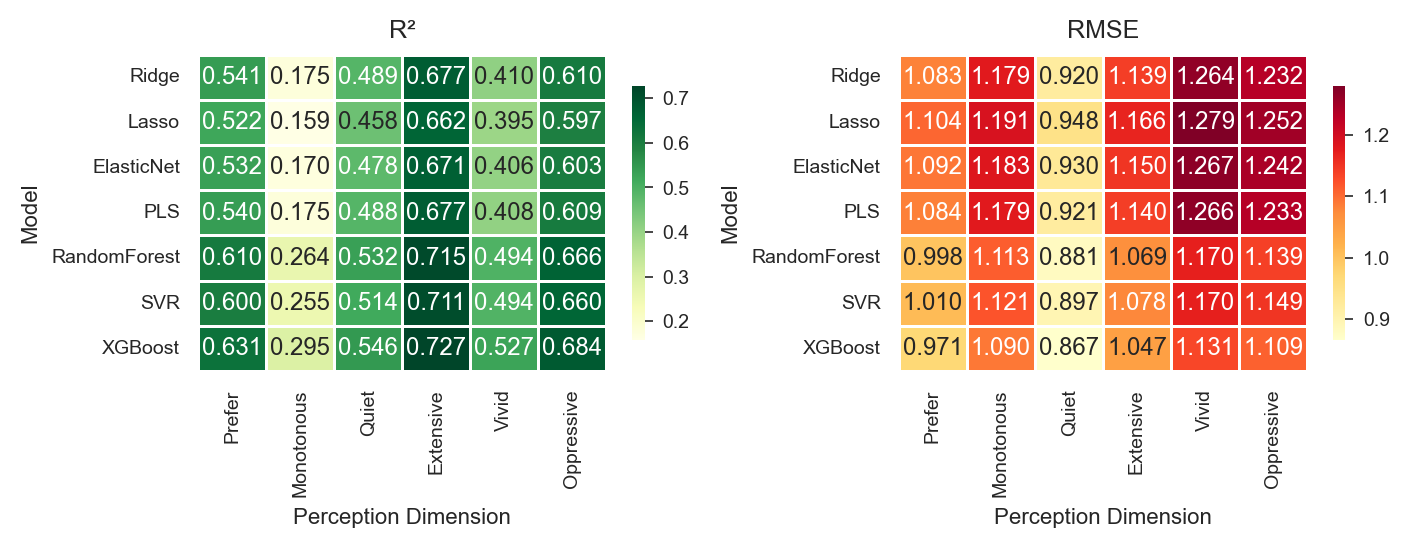

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM))

for ax, data, title in zip(axes,
                            [r2_scores.astype(float), rmse_scores.astype(float)],
                            ['R²', 'RMSE']):
    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd' if title == 'RMSE' else 'YlGn',
        linewidths=0.4,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title)
    ax.set_xlabel('Perception Dimension')
    ax.set_ylabel('Model')

plt.tight_layout()
savefig_all(fig, 'figures/inference_model_heatmap')
plt.show()